# Without Feature Engineering and With Feature Engineering

---
## Rawdatasetni yuklash

In [528]:
import pandas as pd
df=pd.read_csv('College.csv')

In [529]:
# Private     -> Universitet xususiy (Yes) yoki davlat (No)
# Apps        -> Qabul uchun kelgan arizalar soni
# Accept      -> Qabul qilingan ariza soni
# Enroll      -> Haqiqatda o'qishga kirgan talabalar soni
# Top10perc   -> O'z maktabida top 10% dan kelgan talabalar foizi
# Top25perc   -> O'z maktabida top 25% dan kelgan talabalar foizi
# F.Undergrad -> Kunduzgi (full-time) bakalavr talabalar soni
# P.Undergrad -> Sirtqi (part-time) bakalavr talabalar soni
# Outstate    -> Boshqa shtatdan kelgan talabalar to'laydigan to'lov ($)
# Room.Board  -> Yotoqxona + ovqat xarajati ($)
# Books       -> Kitoblar uchun taxminiy xarajat ($)
# Personal    -> Shaxsiy xarajatlar ($)
# PhD         -> PhD darajali o'qituvchilar foizi (%)
# Terminal    -> Terminal daraja (PhD yoki eng yuqori) li o'qituvchilar foizi
# S.F.Ratio   -> Talaba / O'qituvchi nisbati (Student-Faculty Ratio)
# perc.alumni -> Xayr-ehson qiluvchi sobiq talabalar foizi
# Expend      -> Har bir talabaga sarflangan xarajat ($)
# Grad.Rate   -> Bitirish darajasi — necha % talaba muvaffaqiyatli bitirgan
# 18ta ustun
# Grad.Rate -> Target (regression)
# Private   -> Target (classification) - mantiqsiz lekin sinab ko'ramiz

In [530]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Private      777 non-null    str    
 1   Apps         777 non-null    int64  
 2   Accept       777 non-null    int64  
 3   Enroll       777 non-null    int64  
 4   Top10perc    777 non-null    int64  
 5   Top25perc    777 non-null    int64  
 6   F.Undergrad  777 non-null    int64  
 7   P.Undergrad  777 non-null    int64  
 8   Outstate     777 non-null    int64  
 9   Room.Board   777 non-null    int64  
 10  Books        777 non-null    int64  
 11  Personal     777 non-null    int64  
 12  PhD          777 non-null    int64  
 13  Terminal     777 non-null    int64  
 14  S.F.Ratio    777 non-null    float64
 15  perc.alumni  777 non-null    int64  
 16  Expend       777 non-null    int64  
 17  Grad.Rate    777 non-null    int64  
dtypes: float64(1), int64(16), str(1)
memory usage: 109.4 KB


In [531]:
df.shape

(777, 18)

In [532]:
# Dataset shakli
display(df.head())

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [533]:
# Ustunlar va turlari
df.dtypes

Private            str
Apps             int64
Accept           int64
Enroll           int64
Top10perc        int64
Top25perc        int64
F.Undergrad      int64
P.Undergrad      int64
Outstate         int64
Room.Board       int64
Books            int64
Personal         int64
PhD              int64
Terminal         int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate        int64
dtype: object

In [534]:
# Statistik tavsif
display(df.describe())

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


---
## Preprocessing

In [535]:
df.isnull().sum()

Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64

In [536]:
# Missing qiymatlari yo'q
def tozala(df):
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype=="str":
                df[col]=df[col].fillna(df[col].mode()[0])
            else:
                df[col]=df[col].fillna(df[col].mean())
    return df

In [537]:
df=tozala(df)

In [538]:
# encoding

In [539]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Private      777 non-null    str    
 1   Apps         777 non-null    int64  
 2   Accept       777 non-null    int64  
 3   Enroll       777 non-null    int64  
 4   Top10perc    777 non-null    int64  
 5   Top25perc    777 non-null    int64  
 6   F.Undergrad  777 non-null    int64  
 7   P.Undergrad  777 non-null    int64  
 8   Outstate     777 non-null    int64  
 9   Room.Board   777 non-null    int64  
 10  Books        777 non-null    int64  
 11  Personal     777 non-null    int64  
 12  PhD          777 non-null    int64  
 13  Terminal     777 non-null    int64  
 14  S.F.Ratio    777 non-null    float64
 15  perc.alumni  777 non-null    int64  
 16  Expend       777 non-null    int64  
 17  Grad.Rate    777 non-null    int64  
dtypes: float64(1), int64(16), str(1)
memory usage: 109.4 KB


In [540]:
# encoding 
# (1ta Private holos ekan u keyinchali target qiymat bo'lishi mumkinligi uchun 0 va 1 qilib o'zgartiramiz)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Private'] = le.fit_transform(df['Private'])
df['Private'].value_counts()

Private
1    565
0    212
Name: count, dtype: int64

In [541]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Private      777 non-null    int64  
 1   Apps         777 non-null    int64  
 2   Accept       777 non-null    int64  
 3   Enroll       777 non-null    int64  
 4   Top10perc    777 non-null    int64  
 5   Top25perc    777 non-null    int64  
 6   F.Undergrad  777 non-null    int64  
 7   P.Undergrad  777 non-null    int64  
 8   Outstate     777 non-null    int64  
 9   Room.Board   777 non-null    int64  
 10  Books        777 non-null    int64  
 11  Personal     777 non-null    int64  
 12  PhD          777 non-null    int64  
 13  Terminal     777 non-null    int64  
 14  S.F.Ratio    777 non-null    float64
 15  perc.alumni  777 non-null    int64  
 16  Expend       777 non-null    int64  
 17  Grad.Rate    777 non-null    int64  
dtypes: float64(1), int64(17)
memory usage: 109.4 KB


In [542]:
# Scaling
df.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,1,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,1,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,1,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,1,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [543]:
# from sklearn.preprocessing import MinMaxScaler
# def scale_qil(df):
#    mms = MinMaxScaler()
#    for col in df.columns:
#        num_col = df.select_dtypes(include=['int64','float64']).columns.drop('Grad.Rate')
#        df[num_col] = mms.fit_transform(df[num_col])
#    return df
# df=scale_qil(df)

In [544]:
df.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,1,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,1,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,1,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,1,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


---
## Without Feature Engineering

In [545]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Grad.Rate','Private'])
y = df['Grad.Rate']

X.shape, y.shape

((777, 16), (777,))

In [546]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [547]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# feature qismlarinigina scaling qilamiz
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

---
## Regression

In [548]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [549]:
# Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print("r2: ", r2_lr)
print("mse: ", mse_lr)
print("mae: ", mae_lr)

r2:  0.49970297311023115
mse:  117.67117231842153
mae:  8.245824384622287


In [550]:
# Ridge Regression (L1)
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=0.1)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)
r2_ridge = r2_score(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
print("r2: ", r2_ridge)
print("mse: ", mse_ridge)
print("mae: ", mae_ridge)

r2:  0.4997412751501398
mse:  117.66216357822123
mae:  8.245975055318361


In [551]:
# Lasso Regression (L2)
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_sc, y_train)
y_pred_lasso = lasso.predict(X_test_sc)
r2_lasso = r2_score(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
print("r2: ", r2_lasso)
print("mse: ", mse_lasso)
print("mae: ", mae_lasso)

r2:  0.5092464884099797
mse:  115.42651250034984
mae:  8.200464590559468


In [552]:
# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor()
dtr.fit(X_train_sc, y_train)
y_pred_dtr = dtr.predict(X_test_sc)
r2_dtr = r2_score(y_test, y_pred_dtr)
mse_dtr = mean_squared_error(y_test, y_pred_dtr)
mae_dtr = mean_absolute_error(y_test, y_pred_dtr)
print("r2: ", r2_dtr)
print("mse: ", mse_dtr)
print("mae: ", mae_dtr)

r2:  -0.4158550538436179
mse:  333.0128205128205
mae:  14.346153846153847


In [553]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(X_train_sc, y_train)
y_pred_rfr = rfr.predict(X_test_sc)
r2_rfr = r2_score(y_test, y_pred_rfr)
mse_rfr = mean_squared_error(y_test, y_pred_rfr)
mae_rfr = mean_absolute_error(y_test, y_pred_rfr)
print("r2: ", r2_rfr)
print("mse: ", mse_rfr)
print("mae: ", mae_rfr)

r2:  0.5376866462341787
mse:  108.73731282051283
mae:  7.94602564102564


In [554]:
# SVR
from sklearn.svm import SVR
svr = SVR(kernel='linear', C=1.0)
svr.fit(X_train_sc, y_train)
y_pred_svr = svr.predict(X_test_sc)
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
print("r2: ", r2_svr)
print("mse: ", mse_svr)
print("mae: ", mae_svr)

r2:  0.4915902102958216
mse:  119.57931540103712
mae:  8.230495153001831


---
## Classification

In [555]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Private'])
y = df['Private']

X.shape, y.shape

((777, 17), (777,))

In [556]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [557]:
from sklearn.metrics import classification_report, accuracy_score

In [558]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lgr = LogisticRegression()
lgr.fit(X_train_sc, y_train)
y_pred_lgr = lgr.predict(X_test_sc)
class_lgr = classification_report(y_test, y_pred_lgr)
acc_lgr = accuracy_score(y_test, y_pred_lgr)
print("class: ", class_lgr)
print("acc: ", acc_lgr)

class:                precision    recall  f1-score   support

           0       0.85      0.87      0.86        47
           1       0.94      0.94      0.94       109

    accuracy                           0.92       156
   macro avg       0.90      0.90      0.90       156
weighted avg       0.92      0.92      0.92       156

acc:  0.9166666666666666


In [559]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train_sc, y_train)
y_pred_dtc = dtc.predict(X_test_sc)
class_dtc = classification_report(y_test, y_pred_dtc)
acc_dtc = accuracy_score(y_test, y_pred_dtc)
print("class: ", class_dtc)
print("acc: ", acc_dtc)

class:                precision    recall  f1-score   support

           0       0.72      0.83      0.77        47
           1       0.92      0.86      0.89       109

    accuracy                           0.85       156
   macro avg       0.82      0.85      0.83       156
weighted avg       0.86      0.85      0.86       156

acc:  0.8525641025641025


In [560]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train_sc, y_train)
y_pred_rfc = rfc.predict(X_test_sc)
class_rfc = classification_report(y_test, y_pred_rfc)
acc_rfc = accuracy_score(y_test, y_pred_rfc)
print("class: ", class_rfc)
print("acc: ", acc_rfc)

class:                precision    recall  f1-score   support

           0       0.88      0.89      0.88        47
           1       0.95      0.94      0.95       109

    accuracy                           0.93       156
   macro avg       0.91      0.92      0.92       156
weighted avg       0.93      0.93      0.93       156

acc:  0.9294871794871795


In [561]:
# SVC
from sklearn.svm import SVC
svc = SVC(kernel='rbf', C=1.0)
svc.fit(X_train_sc, y_train)
y_pred_svc = svc.predict(X_test_sc)
class_svc = classification_report(y_test, y_pred_svc)
acc_svc = accuracy_score(y_test, y_pred_svc)
print("class: ", class_svc)
print("acc: ", acc_svc)

class:                precision    recall  f1-score   support

           0       0.87      0.87      0.87        47
           1       0.94      0.94      0.94       109

    accuracy                           0.92       156
   macro avg       0.91      0.91      0.91       156
weighted avg       0.92      0.92      0.92       156

acc:  0.9230769230769231


---
## With Feature Engineering

In [562]:
# Acceptance Rate - qabul qilinganlar nisbati
X_fe = X.copy()
# Apps — universitetga ariza berganlar soni, Accept — qabul qilinganlar soni
X_fe['Accept_Rate'] = X_fe['Accept'] / X_fe['Apps'] # necha foizi qabul qilinganini ko'rsatish
# Accept — qabul qilinganlar soni, Enroll — haqiqatda o'qishga kirganlar soni
X_fe['Enroll_Rate'] = X_fe['Enroll'] / X_fe['Accept'] # qabul qilinganlarni necha foizi o'qishga kirganini ko'rsatadi

In [563]:
# Train/Test split va Scaling — WITH FE
from sklearn.model_selection import train_test_split
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_fe, y, test_size=0.2, random_state=42
)

from sklearn.preprocessing import StandardScaler
sc2 = StandardScaler()
X_tr2_sc = sc2.fit_transform(X_tr2)
X_te2_sc = sc2.transform(X_te2)

---
## Regression with FE

In [564]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [565]:
# Linear Regression + FE
from sklearn.linear_model import LinearRegression
lr2 = LinearRegression()
lr2.fit(X_tr2_sc, y_tr2)
y_pred_lr2 = lr2.predict(X_te2_sc)
r2_lr2 = r2_score(y_te2, y_pred_lr2)
mse_lr2 = mean_squared_error(y_te2, y_pred_lr2)
mae_lr2 = mean_absolute_error(y_te2, y_pred_lr2)
print("r2: ", r2_lr2)
print("mse: ", mse_lr2)
print("mae: ", mae_lr2)

r2:  0.6078093029017143
mse:  0.08256052519865704
mae:  0.21666993541988128


In [566]:
# Ridge + fe
from sklearn.linear_model import Ridge
ridge2 = Ridge(alpha=1.0)
ridge2.fit(X_tr2_sc, y_tr2)
y_pred_ridge2 = ridge2.predict(X_te2_sc)
r2_ridge2 = r2_score(y_te2, y_pred_ridge2)
mse_ridge2 = mean_squared_error(y_te2, y_pred_ridge2)
mae_ridge2 = mean_absolute_error(y_te2, y_pred_ridge2)
print("r2: ", r2_ridge2)
print("mse: ", mse_ridge2)
print("mae: ", mae_ridge2)

r2:  0.609125392576289
mse:  0.08228347361241256
mae:  0.21624801114812497


In [567]:
# Lasso + fe
from sklearn.linear_model import Lasso
lasso2 = Lasso(alpha=0.1)
lasso2.fit(X_tr2_sc, y_tr2)
y_pred_lasso2 = lasso2.predict(X_te2_sc)
r2_lasso2 = r2_score(y_te2, y_pred_lasso2)
mse_lasso2 = mean_squared_error(y_te2, y_pred_lasso2)
mae_lasso2 = mean_absolute_error(y_te2, y_pred_lasso2)
print("r2: ", r2_lasso2)
print("mse: ", mse_lasso2)
print("mae: ", mae_lasso2)

r2:  0.5422498503700179
mse:  0.09636152270522673
mae:  0.2587806075938045


In [568]:
# DecisionTreeRegressor + fe
from sklearn.tree import DecisionTreeRegressor
dtr2 = DecisionTreeRegressor(random_state=42)
dtr2.fit(X_tr2_sc, y_tr2)
y_pred_dtr2 = dtr2.predict(X_te2_sc)
r2_dtr2 = r2_score(y_te2, y_pred_dtr2)
mse_dtr2 = mean_squared_error(y_te2, y_pred_dtr2)
mae_dtr2 = mean_absolute_error(y_te2, y_pred_dtr2)
print("r2: ", r2_dtr2)
print("mse: ", mse_dtr2)
print("mae: ", mae_dtr2)

r2:  0.2996291235604138
mse:  0.14743589743589744
mae:  0.14743589743589744


In [569]:
# RandomForestRegressor + fe
from sklearn.ensemble import RandomForestRegressor
rfr2 = RandomForestRegressor(n_estimators=100, random_state=42)
rfr2.fit(X_tr2_sc, y_tr2)
y_pred_rfr2 = rfr2.predict(X_te2_sc)
r2_rfr2 = r2_score(y_te2, y_pred_rfr2)
mse_rfr2 = mean_squared_error(y_te2, y_pred_rfr2)
mae_rfr2 = mean_absolute_error(y_te2, y_pred_rfr2)
print("r2: ", r2_rfr2)
print("mse: ", mse_rfr2)
print("mae: ", mae_rfr2)

r2:  0.7423883661916846
mse:  0.0542301282051282
mae:  0.1098076923076923


In [570]:
# SVR + fe
from sklearn.svm import SVR
svr2 = SVR(kernel='rbf')
svr2.fit(X_tr2_sc, y_tr2)
y_pred_svr2 = svr2.predict(X_te2_sc)
r2_svr2 = r2_score(y_te2, y_pred_svr2)
mse_svr2 = mean_squared_error(y_te2, y_pred_svr2)
mae_svr2 = mean_absolute_error(y_te2, y_pred_svr2)
print("r2: ", r2_svr2)
print("mse: ", mse_svr2)
print("mae: ", mae_svr2)

r2:  0.6890689729853321
mse:  0.06545445641831622
mae:  0.16397756760670457


---
## Classification + FE

In [ ]:
# with FE - yangi featurelar qo'shish
X_fe = df.drop(columns=['Private'])
y = df['Private']

# Feature Engineering
# Xususiy universitetlar har bir talabaga ancha ko'p pul sarflaydi — bu Private ni ajratib berishga yordam beradi
# Expend — universitet har bir talabaga yillik sarflagan pul
# F.Undergrad($) — kunduzgi (full-time) bakalavr talabalar soni
X_fe['Expend_per_Student'] = X_fe['Expend'] / (X_fe['F.Undergrad'] + 1) # nima uchun ...+1 -> Agar F.Undergrad = 0 bo'lsa xato chiqmasligi uchun

In [572]:
X_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Apps                777 non-null    int64  
 1   Accept              777 non-null    int64  
 2   Enroll              777 non-null    int64  
 3   Top10perc           777 non-null    int64  
 4   Top25perc           777 non-null    int64  
 5   F.Undergrad         777 non-null    int64  
 6   P.Undergrad         777 non-null    int64  
 7   Outstate            777 non-null    int64  
 8   Room.Board          777 non-null    int64  
 9   Books               777 non-null    int64  
 10  Personal            777 non-null    int64  
 11  PhD                 777 non-null    int64  
 12  Terminal            777 non-null    int64  
 13  S.F.Ratio           777 non-null    float64
 14  perc.alumni         777 non-null    int64  
 15  Expend              777 non-null    int64  
 16  Grad.Rate          

In [573]:
# Train/Test split va Scaling — WITH FE
from sklearn.model_selection import train_test_split
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_fe, y, test_size=0.2, random_state=42
)

from sklearn.preprocessing import StandardScaler
sc2 = StandardScaler()
X_tr2_sc = sc2.fit_transform(X_tr2)
X_te2_sc = sc2.transform(X_te2)

In [574]:
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_fe, y, test_size=0.2, random_state=42
    )

In [575]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lgr2 = LogisticRegression()
lgr2.fit(X_tr2_sc, y_tr2)
y_pred_lgr2 = lgr2.predict(X_te2_sc)
class_lgr2 = classification_report(y_te2, y_pred_lgr2)
acc_lgr2 = accuracy_score(y_te2, y_pred_lgr2)
print("class: ", class_lgr2)
print("acc: ", acc_lgr2)

class:                precision    recall  f1-score   support

           0       0.84      0.91      0.88        47
           1       0.96      0.93      0.94       109

    accuracy                           0.92       156
   macro avg       0.90      0.92      0.91       156
weighted avg       0.93      0.92      0.92       156

acc:  0.9230769230769231


In [576]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
dtc2 = DecisionTreeClassifier()
dtc2.fit(X_tr2_sc, y_tr2)
y_pred_dtc2 = dtc2.predict(X_te2_sc)
class_dtc2 = classification_report(y_te2, y_pred_dtc2)
acc_dtc2 = accuracy_score(y_te2, y_pred_dtc2)
print("class: ", class_dtc2)
print("acc: ", acc_dtc2)

class:                precision    recall  f1-score   support

           0       0.75      0.83      0.79        47
           1       0.92      0.88      0.90       109

    accuracy                           0.87       156
   macro avg       0.84      0.86      0.84       156
weighted avg       0.87      0.87      0.87       156

acc:  0.8653846153846154


In [577]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rfc2 = RandomForestClassifier(n_estimators=100, random_state=42)
rfc2.fit(X_tr2_sc, y_tr2)
y_pred_rfc2 = rfc2.predict(X_te2_sc)
class_rfc2 = classification_report(y_te2, y_pred_rfc2)
acc_rfc2 = accuracy_score(y_te2, y_pred_rfc2)
print("class: ", class_rfc2)
print("acc: ", acc_rfc2)

class:                precision    recall  f1-score   support

           0       0.88      0.91      0.90        47
           1       0.96      0.94      0.95       109

    accuracy                           0.94       156
   macro avg       0.92      0.93      0.92       156
weighted avg       0.94      0.94      0.94       156

acc:  0.9358974358974359


In [578]:
# SVC
from sklearn.svm import SVC
svc2 = SVC(kernel='linear', C=0.1)
svc2.fit(X_tr2_sc, y_tr2)
y_pred_svc2 = svc2.predict(X_te2_sc)
class_svc2 = classification_report(y_te2, y_pred_svc2)
acc_svc2 = accuracy_score(y_te2, y_pred_svc2)
print("class: ", class_svc2)
print("acc: ", acc_svc2)

# svc2 = SVC(kernel='linear', C=0.1) -> nu qismini o'zgartirdik va natija biroz yaxshilashdi

class:                precision    recall  f1-score   support

           0       0.88      0.91      0.90        47
           1       0.96      0.94      0.95       109

    accuracy                           0.94       156
   macro avg       0.92      0.93      0.92       156
weighted avg       0.94      0.94      0.94       156

acc:  0.9358974358974359


---
# Natijalarni taqqoslash - Tabulate

## Regression

In [610]:
from tabulate import tabulate

rows_reg = [
    ['Linear Regression', round(r2_lr, 2), round(r2_lr2, 2), round(mae_lr, 2), round(mae_lr2, 2), round(mse_lr, 2), round(mse_lr2, 2)],
    ['Ridge',             round(r2_ridge, 2), round(r2_ridge2, 2), round(mae_ridge, 2), round(mae_ridge2, 2), round(mse_ridge, 2), round(mse_ridge2, 2)],
    ['Lasso',             round(r2_lasso, 2), round(r2_lasso2, 2), round(mae_lasso, 2), round(mae_lasso2, 2), round(mse_lasso, 2), round(mse_lasso2, 2)],
    ['Decision Tree',     round(r2_dtr, 2), round(r2_dtr2, 2), round(mae_dtr, 2), round(mae_dtr2, 2), round(mse_dtr, 2), round(mse_dtr2, 2)],
    ['Random Forest',     round(r2_rfr, 2), round(r2_rfr2, 2), round(mae_rfr, 2), round(mae_rfr2, 2), round(mse_rfr, 2), round(mse_rfr2, 2)],
    ['SVR',               round(r2_svr, 2), round(r2_svr2, 2), round(mae_svr, 2), round(mae_svr2, 2), round(mse_svr, 2), round(mse_svr2, 2)],
]

print(tabulate(rows_reg, headers=['Model', 'R2', 'R2 + FE', 'MAE', 'MAE + FE', 'MSE', 'MSE + FE'], tablefmt='fancy_grid'))

╒═══════════════════╤═══════╤═══════════╤═══════╤════════════╤════════╤════════════╕
│ Model             │    R2 │   R2 + FE │   MAE │   MAE + FE │    MSE │   MSE + FE │
╞═══════════════════╪═══════╪═══════════╪═══════╪════════════╪════════╪════════════╡
│ Linear Regression │  0.5  │      0.61 │  8.25 │       0.22 │ 117.67 │       0.08 │
├───────────────────┼───────┼───────────┼───────┼────────────┼────────┼────────────┤
│ Ridge             │  0.5  │      0.61 │  8.25 │       0.22 │ 117.66 │       0.08 │
├───────────────────┼───────┼───────────┼───────┼────────────┼────────┼────────────┤
│ Lasso             │  0.51 │      0.54 │  8.2  │       0.26 │ 115.43 │       0.1  │
├───────────────────┼───────┼───────────┼───────┼────────────┼────────┼────────────┤
│ Decision Tree     │ -0.42 │      0.3  │ 14.35 │       0.15 │ 333.01 │       0.15 │
├───────────────────┼───────┼───────────┼───────┼────────────┼────────┼────────────┤
│ Random Forest     │  0.54 │      0.74 │  7.95 │       0.11 │ 10

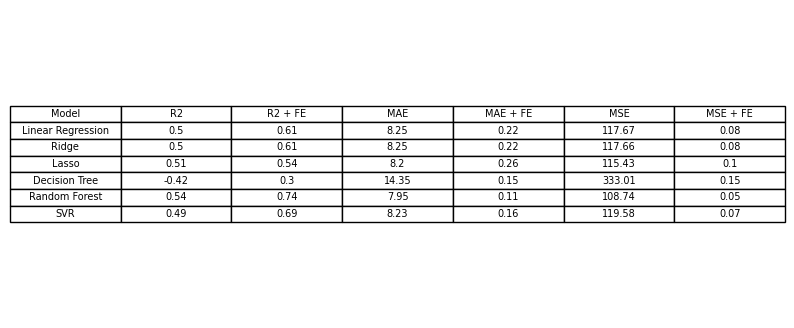

In [611]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
table = ax.table(
    cellText=rows_reg,
    colLabels=['Model', 'R2','R2 + FE', 'MAE', 'MAE + FE', 'MSE', 'MSE + FE'],
    loc='center',
    cellLoc='center'
)
plt.show()

## Classification

In [618]:
from tabulate import tabulate

rows_clf = [
    ['Logistic Regression',            round(acc_lgr, 3), round(acc_lgr2, 3)],
    ['Decision Tree Classifier',       round(acc_dtc, 3),  round(acc_dtc2, 3)],
    ['Random Forest Classifier',       round(acc_rfc, 3),  round(acc_rfc2, 3)],
    ['SVC',                            round(acc_svc, 3), round(acc_svc2, 3)]
]

print(tabulate(rows_clf, headers=['Model', 'Acc', 'Acc+FE', 'Prec', 'Prec+FE', 'Rec', 'Rec+FE', 'F1', 'F1+FE'], tablefmt='fancy_grid'))

╒══════════════════════════╤═══════╤══════════╕
│ Model                    │   Acc │   Acc+FE │
╞══════════════════════════╪═══════╪══════════╡
│ Logistic Regression      │ 0.917 │    0.923 │
├──────────────────────────┼───────┼──────────┤
│ Decision Tree Classifier │ 0.853 │    0.865 │
├──────────────────────────┼───────┼──────────┤
│ Random Forest Classifier │ 0.929 │    0.936 │
├──────────────────────────┼───────┼──────────┤
│ SVC                      │ 0.923 │    0.936 │
╘══════════════════════════╧═══════╧══════════╛


---
# Classga oid misol

a_b_add(1,2)a_b_add(1,10)

In [3]:
# funksiya
def a_b_add(a,b):
    return a+b
a_b_add(4,7)

11

In [11]:
class Xisobla:
    def __init__(self,a,b):
        self.a=a
        self.b=b
    def add(self):
        return self.a+self.b
    def kop(self):
        return self.a*self.b
    def orta(self):
        return (self.a+self.b)/2

In [12]:
natija=Xisobla(5,6)
natija.add()

11

In [13]:
natija.kop()

30

In [14]:
natija.orta()

5.5